<h1 style="color:green;font-size:22px;">Function 3 - Black-Box Optimisation</h1>
<h1 style="color:#0000CD;font-size:19px;">Objective and reading guide</h1>

Function 3 is a three-dimensional black-box objective over the bounded domain $[0,1]^3$. Its analytical form and interpretation are unknown. The objective is to **find the input configuration that maximises the observed value of Function 3** under a limited sequential-evaluation budget.

As a purely illustrative analogy, consider a drug-discovery screening problem in which the three inputs represent quantities of three compounds and each experiment returns a single scalar screening score. This analogy is intended only to illustrate sequential experimental design under a limited query budget.

The 13 historical queries are organised by strategy phase:

1. **Global RBF-UCB exploration** (Weeks 1–5)
2. **Global RBF-EI improvement search** (Weeks 6–8)
3. **Local Matérn-5/2 EI refinement** (Weeks 9–13)

The notebook keeps the settings that affected the historical decisions, but the emphasis is on why the search changed, what the returned observations implied, and whether the main decisions are robust to reasonable modelling and search choices.

In [1]:
# Standard libraries
import sys
import warnings
from itertools import combinations
from pathlib import Path

# Numerical computing, data handling and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

# BBO project root
ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# BBO project package
from src.config import RANDOM_SEED
from src.data import load_initial_data, extract, update_data, historical_record
from src.acquisition import upper_confidence_bound, expected_improvement

from src.search import (
    cartesian_grid,
    search_region,
    random_candidates,
    filter_candidates,
    run_search_strategy)

from src.plotting import (
    plot_sequential_query_performance,  
    plot_pairwise_observations_2d, 
    plot_initial_landscape_3d, 
    plot_search_path_3d)

from src.validation import (
    sequential_performance,
    kernel_choice_validation,
    cartesian_resolution_sensitivity)

FUNCTION_ID = 3
DIMENSION = 3

warnings.filterwarnings("ignore", category=ConvergenceWarning)

<h1 style="color:#0000CD;font-size:19px;">1. Initial observations</h1>

**1.1 - Extraction of initial data**

The experiment starts with **15 observations**. Before fitting a surrogate, the first step is to inspect the scale and spatial coverage of the observed responses and identify the initial incumbent.

In [2]:
data = load_initial_data(FUNCTION_ID)
inputs, outputs = extract(data)

display(data)

initial_best_idx = np.argmax(outputs)
print(f"Initial observations: {len(outputs)}")
print(f"Initial best: {outputs[initial_best_idx]:.6f}")
print(f"Initial best location: {inputs[initial_best_idx]}")

,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


Initial observations: 15
Initial best: -0.034835
Initial best location: [0.49258141 0.61159319 0.34017639]


**1.2 - 3D Exploration** 

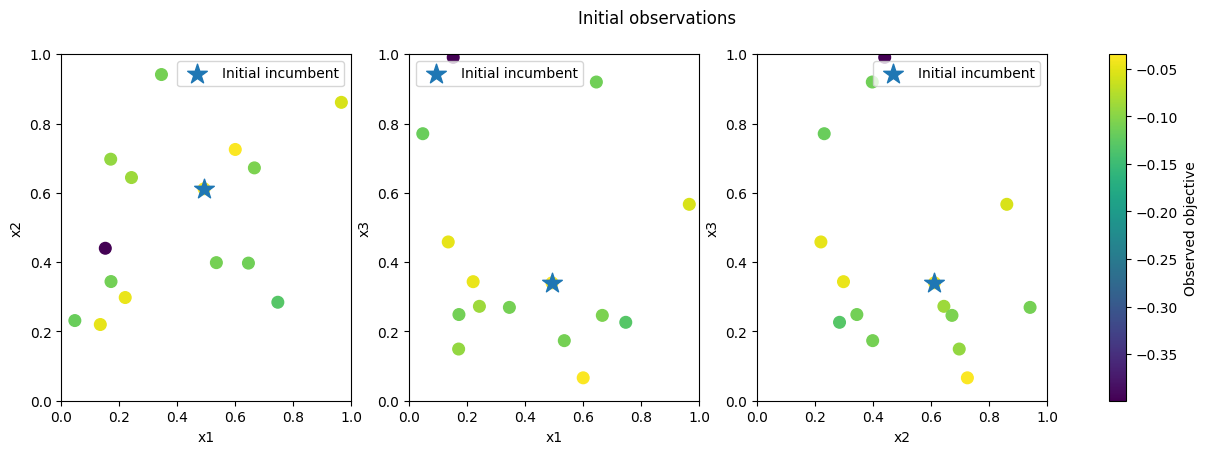

In [3]:
plot_pairwise_observations_2d(inputs, outputs)

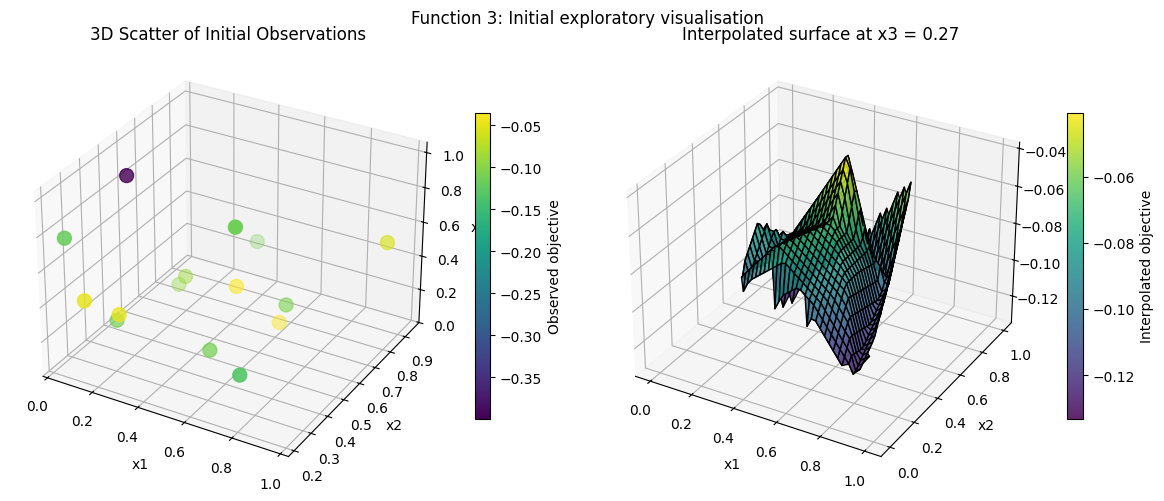

In [4]:
plot_initial_landscape_3d(data)

**Observations:**

- The 15 initial observations are distributed across the three-dimensional domain, but remain sparse.
- The best initial observation is approximately -0.034835 at [0.492581, 0.611593, 0.340176].
- The 3D scatter does not reveal a sufficiently dense concentration of strong observations to identify a clear local optimum.
- The interpolated surface is evaluated at the median observed x3 and therefore represents only a two-dimensional slice through the three-dimensional data.

**Interpretation:**

The 3D scatter represents the actual evaluated observations, whereas the surface is a linear interpolation across the (x1, x2) plane at a fixed x3. The interpolated slice suggests potentially favourable values in a region that does not exactly coincide with the best observed point. This difference is expected because the surface represents only one cross-section of the full three-dimensional domain and is inferred from sparse data.

The interpolated surface is therefore used only as an exploratory visualisation, not to select the next query. Overall, the initial evidence remains too limited to justify localising the search, supporting a full-domain exploration strategy.

<h1 style="color:#0000CD;font-size:19px;">2. Phase 1: Global RBF-UCB exploration (Weeks 1–5)</h1>

The first phase uses a Gaussian Process with an RBF kernel and UCB over the full three-dimensional domain.

- **Surrogate:** Gaussian Process with RBF kernel, initial length scale $0.2$.
- **Candidate grid:** $50^3=125{,}000$ points for Weeks 1–4, increased to $100^3=1{,}000{,}000$ in Week 5.
- **Acquisition:** UCB with $\kappa=1.5$ for Weeks 1–3, $\kappa=4.0$ in Week 4 to increase exploration, and $\kappa=2/\sqrt{5}$ in Week 5 to reduce exploration.
- **Sequential update:** each recommendation is reconstructed from the observations available at that week, then the recorded historical observation is appended.

The RBF value $0.2$ is an initial GP length scale, not a fixed one; the GP re-optimises the length scale at each step and no explicit length-scale bounds are imposed.

In [5]:
X_grid_50 = cartesian_grid(DIMENSION, 50)
X_grid_100 = cartesian_grid(DIMENSION, 100)

def rbf_kernel(initial_length_scale=0.2):
    return RBF(length_scale=initial_length_scale)+ WhiteKernel(noise_level=1e-6)

phase_1_settings = { 1: {"candidates": X_grid_50, "resolution": 50, "kappa": 1.5},
                     2: {"candidates": X_grid_50, "resolution": 50, "kappa": 1.5},
                     3: {"candidates": X_grid_50, "resolution": 50, "kappa": 1.5},
                     4: {"candidates": X_grid_50, "resolution": 50, "kappa": 4.0},
                     5: {"candidates": X_grid_100, "resolution": 100, "kappa": 2 / np.sqrt(5)}}
phase_1_rows = []

for week, settings in phase_1_settings.items():
    
    inputs, outputs = extract(data)
    previous_best = float(outputs.max())

    proposed_point, acquisition_values = run_search_strategy(
        inputs,
        outputs,
        settings["candidates"],
        rbf_kernel(0.2),
        upper_confidence_bound,
        kappa=settings["kappa"])

    recorded_point, observed_y = historical_record(FUNCTION_ID, week)

    phase_1_rows.append({
        "week": week,
        "grid_resolution": settings["resolution"],
        "n_candidates": len(settings["candidates"]),
        "kappa": round(settings["kappa"],3),
        "proposed_x1": proposed_point[0],
        "proposed_x2": proposed_point[1],
        "proposed_x3": proposed_point[2],
        "recorded_x1": recorded_point[0],
        "recorded_x2": recorded_point[1],
        "recorded_x3": recorded_point[2],
        "observed_y": observed_y,
        "proposal_distance": np.linalg.norm(proposed_point - recorded_point),
        "matches_record": np.allclose(proposed_point, recorded_point, atol=1e-6),
        "improved_incumbent": observed_y > previous_best})

    data = update_data(data, recorded_point, observed_y)

phase_1_history = pd.DataFrame(phase_1_rows)
display(phase_1_history)

Point added!
Point added!
Point added!
Point added!
Point added!


,week,grid_resolution,n_candidates,kappa,proposed_x1,proposed_x2,proposed_x3,recorded_x1,recorded_x2,recorded_x3,observed_y,proposal_distance,matches_record,improved_incumbent
0,1,50,125000,1.500,0.387755,0.408163,0.489796,0.387755,0.408163,0.489796,-0.028417,0.0,True,True
1,2,50,125000,1.500,0.367347,0.142857,0.428571,0.367347,0.142857,0.428571,-0.032890,0.0,True,False
2,3,50,125000,1.500,0.408163,0.775510,0.000000,0.408163,0.775510,0.000000,-0.113217,0.0,True,False
3,4,50,125000,4.000,0.795918,0.959184,0.000000,0.795918,0.959184,0.000000,-0.140421,0.0,True,False
4,5,100,1000000,0.894,0.303030,0.272727,0.484848,0.303030,0.272727,0.484848,-0.061293,0.0,True,False


**Phase result and transition.** Week 1 improves the initial incumbent, confirming that the global GP-UCB search can identify a stronger region. The subsequent exploratory queries do not improve it, including the deliberately more exploratory Week 4 query. Week 5 increases candidate resolution while reducing $\kappa$, but again does not improve the incumbent.

At this point, the experiment has tested both broad exploration and a denser UCB search. The next phase therefore keeps the full-domain RBF surrogate but switches the acquisition rule from UCB to **Expected Improvement (EI)**, which focuses directly on the probability-weighted magnitude of improvement over the incumbent.

<h1 style="color:#0000CD;font-size:19px;">3. Phase 2: Global RBF-EI improvement search (Weeks 6–8)</h1>

Weeks 6–8 keep the search global but replace UCB with Expected Improvement.

- **Surrogate:** RBF GP, initial length scale $0.2$, optimised without custom bounds.
- **Candidate grid:** $100^3=1{,}000{,}000$ full-domain points.
- **Acquisition:** EI with $\xi=0$.

The phase therefore shifts from uncertainty-weighted exploration toward direct expected improvement over the incumbent.

In [6]:
phase_2_rows = []

for week in range(6, 9):
    
    inputs, outputs = extract(data)
    previous_best = float(outputs.max())

    proposed_point, acquisition_values = run_search_strategy(
        inputs,
        outputs,
        X_grid_100,
        rbf_kernel(0.2),
        expected_improvement,
        best=previous_best,
        xi=0.0)

    recorded_point, observed_y = historical_record(FUNCTION_ID, week)

    phase_2_rows.append({
        "week": week,
        "grid_resolution": 100,
        "n_candidates": len(X_grid_100),
        "acquisition": "EI",
        "xi": 0.0,
        "proposed_x1": proposed_point[0],
        "proposed_x2": proposed_point[1],
        "proposed_x3": proposed_point[2],
        "recorded_x1": recorded_point[0],
        "recorded_x2": recorded_point[1],
        "recorded_x3": recorded_point[2],
        "observed_y": observed_y,
        "proposal_distance": np.linalg.norm(proposed_point - recorded_point),
        "matches_record": np.allclose(proposed_point, recorded_point, atol=1e-6),
        "improved_incumbent": observed_y > previous_best})

    data = update_data(data, recorded_point, observed_y)

phase_2_history = pd.DataFrame(phase_2_rows)
display(phase_2_history)

Point added!
Point added!
Point added!


,week,grid_resolution,n_candidates,acquisition,xi,proposed_x1,proposed_x2,proposed_x3,recorded_x1,recorded_x2,recorded_x3,observed_y,proposal_distance,matches_record,improved_incumbent
0,6,100,1000000,EI,0.0,0.434343,0.525253,0.444444,0.434343,0.525253,0.444444,-0.007682,0.0,True,True
1,7,100,1000000,EI,0.0,0.252525,0.060606,0.313131,0.252525,0.060606,0.313131,-0.134673,0.0,True,False
2,8,100,1000000,EI,0.0,0.414141,0.424242,0.373737,0.414141,0.424242,0.373737,-0.019876,0.0,True,False


**Phase result and transition.** Week 6 produces a substantial improvement, moving the incumbent from roughly **-0.02842** to **-0.00768**. Weeks 7–8 do not improve it.

The strongest evidence is now concentrated around a much better-performing neighbourhood. Continuing to spend one million candidates per query over the entire cube offers diminishing value. The final phase therefore changes both the surrogate and candidate design: a shorter-scale **Matérn-5/2 GP** is searched only within a small local box around the current incumbent.

<h1 style="color:#0000CD;font-size:19px;">4. Phase 3: Local Matérn-5/2 EI refinement (Weeks 9–13)</h1>

The final phase concentrates the search around the current incumbent using local random candidates and a Matérn-5/2 GP.

- **Surrogate:** Matérn-5/2 GP, initial ARD length scales $[0.08,0.08,0.08]$, bounded to $(10^{-3},0.5)$.
- **Local region:** incumbent $\pm[0.05,0.05,0.05]$, clipped to $[0,1]^3$.
- **Candidates:** 100,000 uniformly sampled local points per week.
- **Acquisition:** EI with exploration parameter $\xi=0.001$.

The Matérn kernel allows greater local flexibility than the earlier RBF model, while the restricted candidate region focuses the remaining evaluations around the strongest observed area.

In [7]:
LOCAL_RADIUS = np.full(DIMENSION, 0.05)
LOCAL_CANDIDATES = 100_000
XI = 0.001

def matern_52_kernel(initial_length_scale=None):
    if initial_length_scale is None:
        initial_length_scale = np.full(DIMENSION, 0.08)
    return ConstantKernel(1.0, (1e-3, 1e3))* Matern( length_scale=np.asarray(initial_length_scale, dtype=float), length_scale_bounds=(1e-3, 0.5), nu=2.5)

phase_3_rows = []

for week in range(9,14):
    inputs, outputs = extract(data)
    previous_best = float(outputs.max())
    incumbent_idx = int(np.argmax(outputs))
    incumbent_x = inputs[incumbent_idx].copy()

    lower, upper = search_region(incumbent_x, LOCAL_RADIUS)
    candidates = random_candidates(
        DIMENSION,
        LOCAL_CANDIDATES,
        lower=lower,
        upper=upper,
        seed=RANDOM_SEED)
    candidates = filter_candidates(
        candidates,
        inputs,
        min_distance=1e-6)

    gp = GaussianProcessRegressor(
        kernel=matern_52_kernel(),
        alpha=1e-8,
        normalize_y=True,
        n_restarts_optimizer=20,
        random_state=RANDOM_SEED)
    gp.fit(inputs, outputs)

    mean, std = gp.predict(candidates, return_std=True)
    std = np.maximum(std, 1e-12)
    ei_values = expected_improvement(mean, std, best=previous_best, xi=XI)

    proposed_point = np.round(candidates[np.argmax(ei_values)], 6)
    recorded_point, observed_y = historical_record(FUNCTION_ID, week)

    phase_3_rows.append({
        "week": week,
        "xi": XI,
        "n_candidates": len(candidates),
        "incumbent_x1": incumbent_x[0],
        "incumbent_x2": incumbent_x[1],
        "incumbent_x3": incumbent_x[2],
        "proposed_x1": proposed_point[0],
        "proposed_x2": proposed_point[1],
        "proposed_x3": proposed_point[2],
        "recorded_x1": recorded_point[0],
        "recorded_x2": recorded_point[1],
        "recorded_x3": recorded_point[2],
        "observed_y": observed_y,
        "proposal_distance": np.linalg.norm(proposed_point - recorded_point),
        "matches_record": np.allclose(proposed_point, recorded_point, atol=1e-6),
        "improved_incumbent": observed_y > previous_best})

    data = update_data(data, recorded_point, observed_y)

phase_3_history = pd.DataFrame(phase_3_rows)
display(phase_3_history)

Point added!
Point added!
Point added!
Point added!
Point added!


,week,xi,n_candidates,incumbent_x1,incumbent_x2,incumbent_x3,proposed_x1,proposed_x2,proposed_x3,recorded_x1,recorded_x2,recorded_x3,observed_y,proposal_distance,matches_record,improved_incumbent
0,9,0.001,100000,0.434343,0.525253,0.444444,0.483331,0.574031,0.493681,0.483331,0.574031,0.493681,-0.008646,0.000000,True,False
1,10,0.001,99999,0.434343,0.525253,0.444444,0.384880,0.575208,0.401919,0.384880,0.575208,0.401919,-0.007074,0.000000,True,True
2,11,0.001,100000,0.384880,0.575208,0.401919,0.335500,0.623666,0.450587,0.335500,0.623666,0.450587,-0.013293,0.000000,True,False
3,12,0.001,99999,0.384880,0.575208,0.401919,0.434252,0.624458,0.418494,0.434252,0.624458,0.418494,-0.006264,0.000000,True,True
4,13,0.001,100000,0.434252,0.624458,0.418494,0.483997,0.674332,0.464811,0.483997,0.674332,0.464812,-0.008104,0.000001,True,False


**Phase result.** Local refinement improves the incumbent twice: in **Week 10** and again in **Week 12**. Week 13 does not improve it, so the Week 12 observation remains the final incumbent.

In [8]:
# Compact reconstruction of the full historical query path
inputs, outputs = extract(data)

query_inputs = inputs[len(inputs[:15]):]
query_outputs = outputs[len(outputs[:15]):]

path_rows = []
running_best = float(outputs[:15].max())

for week, (point, value) in enumerate(zip(query_inputs, query_outputs), start=1):
    previous_best = running_best
    running_best = max(running_best, float(value))

    if week <= 5:
        phase = "Global RBF-UCB"
    elif week <= 8:
        phase = "Global RBF-EI"
    else:
        phase = "Local Matérn-EI"

    path_rows.append({
        "week": week,
        "phase": phase,
        "x1": point[0],
        "x2": point[1],
        "x3": point[2],
        "observed_y": value,
        "previous_incumbent": previous_best,
        "best_so_far": running_best,
        "improved_incumbent": value > previous_best,
    })

query_history = pd.DataFrame(path_rows)
display(query_history)

,week,phase,x1,x2,x3,observed_y,previous_incumbent,best_so_far,improved_incumbent
0,1,Global RBF-UCB,0.387755,0.408163,0.489796,-0.028417,-0.034835,-0.028417,True
1,2,Global RBF-UCB,0.367347,0.142857,0.428571,-0.032890,-0.028417,-0.028417,False
2,3,Global RBF-UCB,0.408163,0.775510,0.000000,-0.113217,-0.028417,-0.028417,False
3,4,Global RBF-UCB,0.795918,0.959184,0.000000,-0.140421,-0.028417,-0.028417,False
4,5,Global RBF-UCB,0.303030,0.272727,0.484848,-0.061293,-0.028417,-0.028417,False
5,6,Global RBF-EI,0.434343,0.525253,0.444444,-0.007682,-0.028417,-0.007682,True
6,7,Global RBF-EI,0.252525,0.060606,0.313131,-0.134673,-0.007682,-0.007682,False
7,8,Global RBF-EI,0.414141,0.424242,0.373737,-0.019876,-0.007682,-0.007682,False
8,9,Local Matérn-EI,0.483331,0.574031,0.493681,-0.008646,-0.007682,-0.007682,False
9,10,Local Matérn-EI,0.384880,0.575208,0.401919,-0.007074,-0.007682,-0.007074,True


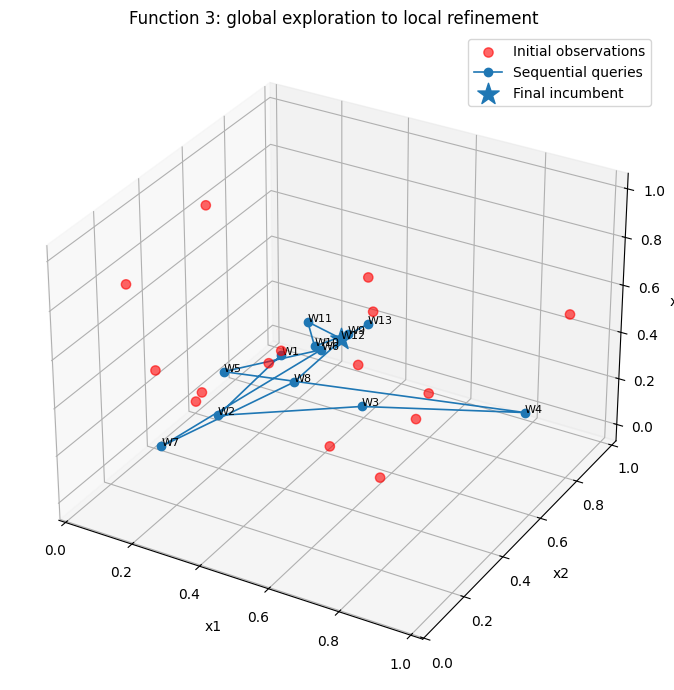

In [9]:
plot_search_path_3d(inputs, outputs, query_inputs)

**Final observed solution.** The best observed point is **$[0.434252,\,0.624458,\,0.418494]$** with objective value approximately **$-0.006264$**, obtained in **Week 12**.

This is the **best observed configuration under the available query budget**, not proof of the global maximum.

<h1 style="color:#0000CD;font-size:19px;">5. Quantitative Evaluation</h1>

The retrospective evaluation separates three questions:

1. **Performance:** how much did the 13-query budget improve the initial incumbent?
2. **Surrogate robustness:** do plausible GP kernels give materially different predictive error or ranking behaviour?
3. **Decision sensitivity:** would reasonable changes to early UCB settings, candidate resolution, or local Matérn assumptions have sent the search to a qualitatively different region?

These checks use only the observations available in the project. They do not reconstruct the hidden objective at unevaluated points.

**5.1 - Sequential and query-budget performance**

Each query is compared with the incumbent available immediately before it.

,metric,value
0,Initial incumbent,-0.034835
1,Final best observed,-0.006264
2,Absolute improvement,0.028571
3,Relative improvement,0.820186
4,Queries improving incumbent,4.000000


,query,query_output,best_so_far,improvement
0,1,-0.028417,-0.028417,0.006418
1,2,-0.032890,-0.028417,0.000000
2,3,-0.113217,-0.028417,0.000000
3,4,-0.140421,-0.028417,0.000000
4,5,-0.061293,-0.028417,0.000000
5,6,-0.007682,-0.007682,0.020735
6,7,-0.134673,-0.007682,0.000000
7,8,-0.019876,-0.007682,0.000000
8,9,-0.008646,-0.007682,0.000000
9,10,-0.007074,-0.007074,0.000608


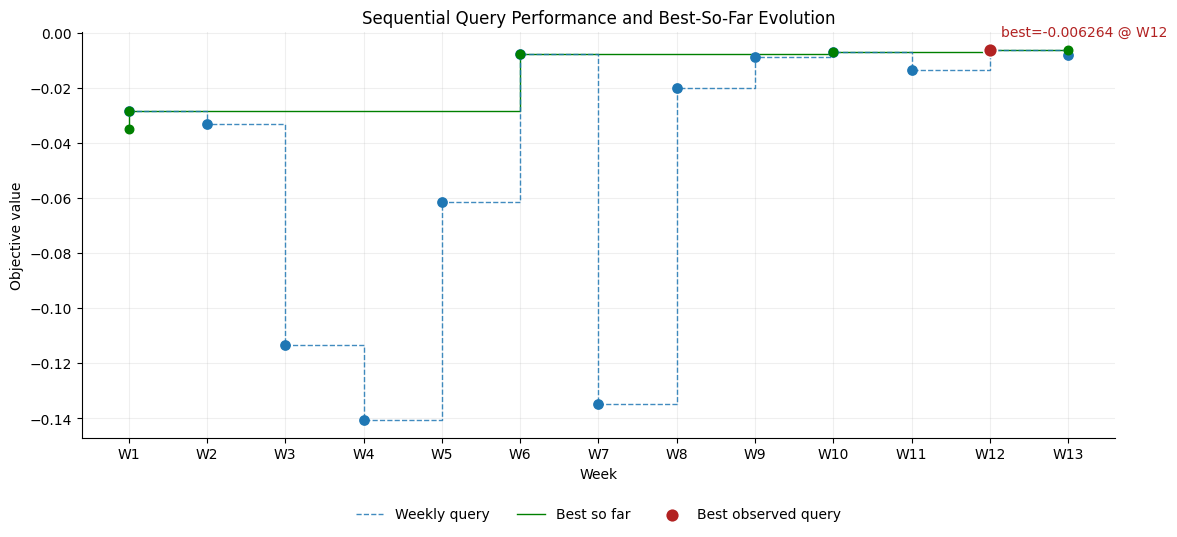

In [13]:
performance, performance_summary = sequential_performance(
    initial_outputs=outputs[:15],
    query_outputs=query_outputs)

summary_display = performance_summary.copy()

if "value" in summary_display.columns:
    value_col = "value"
elif "Value" in summary_display.columns:
    value_col = "Value"
else:
    value_col = summary_display.columns[-1]

display(summary_display)
display(performance)

plot_sequential_query_performance(
    performance,
    FUNCTION_ID,
    yscale="linear",
    plot_type="bar")

**Performance result.** The initial incumbent improves from approximately **-0.034835** to **-0.006264**, an absolute gain of about **0.02857** and a relative improvement of approximately **82.0%** when measured against the magnitude of the initial incumbent.

**4 of the 13** queries directly improve the incumbent: **Weeks 1, 6, 10 and 12**. This phase pattern is important: global UCB finds the first improvement, global EI finds the largest single jump, and local Matérn-EI delivers the two final refinements.

**5.2 - Surrogate robustness**

Because the hidden function is unknown, no kernel can be validated against the true global surface. A more defensible check is therefore out-of-sample prediction on the observed data.

The comparison below uses:

- the historical RBF specification;
- the local Matérn-5/2 specification.

**LOOCV RMSE** measures held-out prediction error, while **Spearman rank correlation** tests whether the surrogate preserves the ordering of relatively good and bad observations.

In [14]:
inputs_eval = inputs.copy()
outputs_eval = outputs.copy()

predictive_kernels = {
    "RBF_fitted": RBF(length_scale=0.2)+ WhiteKernel(noise_level=1e-6),
    "Matern_52": ConstantKernel(1.0, (1e-3, 1e3))* Matern(length_scale=np.full(DIMENSION, 0.08), length_scale_bounds=(1e-3, 0.5), nu=2.5)}

surrogate_robustness = kernel_choice_validation(
    inputs_eval,
    outputs_eval,
    predictive_kernels,
    alpha=1e-10,
    normalize_y=True,
    n_restarts_optimizer=3,
    random_state=RANDOM_SEED)

display(surrogate_robustness)

,kernel,LOOCV_RMSE,Spearman_rank_correlation
0,RBF_fitted,0.078720,0.518336
1,Matern_52,0.071436,0.721949


**Interpretation:** Matérn-5/2 performs best retrospectively among the tested specifications, with both the lowest LOOCV RMSE and the highest Spearman rank correlation. The historical fitted RBF nevertheless performs reasonably well. This supports the early use of the fitted RBF while suggesting that Matérn-5/2 provides a better description of the accumulated data in the later local-refinement phase.

Because the comparison uses the full observed dataset, it is a retrospective robustness check rather than evidence that Matérn-5/2 should necessarily have been chosen from Week 1.

**5.3 - Early RBF decision sensitivity**

The early RBF GP is fitted rather than fixed. The relevant smoothness question is therefore whether changing the **starting length scale** materially changes the fitted model or the Week 1 recommendation.

In [15]:
# Sensitivity of the Week 1 fitted RBF GP to its initial length scale
rbf_initialisation_rows = []

for initial_scale in [0.05, 0.10, 0.20, 0.40]:
    gp = GaussianProcessRegressor(
        kernel=rbf_kernel(initial_scale),
        alpha=1e-10,
        normalize_y=True,
        n_restarts_optimizer=0,
        random_state=RANDOM_SEED)
    gp.fit(inputs[:15], outputs[:15])

    mean, std = gp.predict(X_grid_50, return_std=True)
    scores = upper_confidence_bound(mean, std, kappa=1.5)
    candidate = X_grid_50[np.argmax(scores)]

    fitted_rbf = gp.kernel_.k1.length_scale

    rbf_initialisation_rows.append({
        "initial_length_scale": initial_scale,
        "fitted_length_scale": fitted_rbf,
        "log_marginal_likelihood": gp.log_marginal_likelihood_value_,
        "candidate_x1": candidate[0],
        "candidate_x2": candidate[1],
        "candidate_x3": candidate[2]})

rbf_initialisation_sensitivity = pd.DataFrame(rbf_initialisation_rows)

historical_week_1 = phase_1_history.loc[
    phase_1_history["week"] == 1,
    ["recorded_x1", "recorded_x2", "recorded_x3"],
].to_numpy()[0]

rbf_initialisation_sensitivity["distance_to_historical_week_1"] = (
    np.linalg.norm(
        rbf_initialisation_sensitivity[
            ["candidate_x1", "candidate_x2", "candidate_x3"]
        ].to_numpy()
        - historical_week_1,
        axis=1))

display(rbf_initialisation_sensitivity)

,initial_length_scale,fitted_length_scale,log_marginal_likelihood,candidate_x1,candidate_x2,candidate_x3,distance_to_historical_week_1
0,0.05,0.187566,-20.251094,0.387755,0.408163,0.489796,2.957424e-07
1,0.10,0.187566,-20.251094,0.387755,0.408163,0.489796,2.957424e-07
2,0.20,0.187566,-20.251094,0.387755,0.408163,0.489796,2.957424e-07
3,0.40,0.000010,-21.284078,0.000000,0.000000,0.000000,7.462246e-01


**Interpretation:** Initial scales 0.05, 0.10 and the historical 0.20 converge to the same fitted RBF length scale (≈0.188) and produce the same Week 1 recommendation. The more distant 0.40 start instead converges to a near-zero length scale and a qualitatively different candidate. The historical 0.20 choice is therefore robust to nearby initialisations, although the GP optimisation is not insensitive to arbitrarily different starting values.

**5.3.1 - UCB $\kappa$ sensitivity**

This isolates the exploration–exploitation setting while holding the Week 1 data, fitted GP and $50^3$ candidate grid fixed.

In [16]:
week_1_gp = GaussianProcessRegressor(
    kernel=rbf_kernel(0.2),
    alpha=1e-10,
    normalize_y=True,
    n_restarts_optimizer=0,
    random_state=RANDOM_SEED)
week_1_gp.fit(inputs[:15], outputs[:15])

week_1_mean, week_1_std = week_1_gp.predict(X_grid_50, return_std=True)

kappa_rows = []

for kappa in [1.0, 1.5, 2.0, 2.5, 4.0]:
    scores = upper_confidence_bound(
        week_1_mean,
        week_1_std,
        kappa=kappa)
    candidate = X_grid_50[np.argmax(scores)]

    kappa_rows.append({
        "kappa": kappa,
        "candidate_x1": candidate[0],
        "candidate_x2": candidate[1],
        "candidate_x3": candidate[2],
        "distance_to_historical_week_1": np.linalg.norm(
            candidate - historical_week_1),
        "acquisition_max": scores.max()})

kappa_sensitivity = pd.DataFrame(kappa_rows)
display(kappa_sensitivity)

,kappa,candidate_x1,candidate_x2,candidate_x3,distance_to_historical_week_1,acquisition_max
0,1.0,0.387755,0.408163,0.469388,2.040824e-02,0.035735
1,1.5,0.387755,0.408163,0.489796,2.957424e-07,0.068294
2,2.0,0.408163,0.408163,0.510204,2.886152e-02,0.102423
3,2.5,0.408163,0.408163,0.530612,4.563401e-02,0.137811
4,4.0,0.448980,0.367347,0.551020,9.572267e-02,0.250551


**Interpretation.** Exact coordinates need not remain identical as $\kappa$ changes. The stronger question is whether reasonable values keep the recommendation within the same broad exploratory regime or send it to a qualitatively different part of the cube.

**5.3.2 - Cartesian-grid resolution sensitivity**

A discrete candidate grid can move the numerical argmax simply because a finer lattice offers points that were unavailable on a coarser one. The test below checks whether increasing resolution mainly **refines** the recommendation or materially **relocates** it.

In [17]:
grid_sensitivity = cartesian_resolution_sensitivity(
    gp=week_1_gp,
    dimension=DIMENSION,
    resolutions=[25, 50, 75, 100],
    acquisition="UCB",
    best=float(outputs[:15].max()),
    kappa=1.5)

candidate_matrix = np.vstack(grid_sensitivity["candidate"].to_numpy())

for i in range(DIMENSION):
    grid_sensitivity[f"candidate_x{i + 1}"] = candidate_matrix[:, i]

grid_sensitivity["distance_to_historical_week_1"] = np.linalg.norm(
    candidate_matrix - historical_week_1,
    axis=1)

display(
    grid_sensitivity[
        [ "resolution",
          "n_candidates",
          "candidate_x1",
          "candidate_x2",
          "candidate_x3",
          "distance_to_historical_week_1",
          "acquisition_max"]])

,resolution,n_candidates,candidate_x1,candidate_x2,candidate_x3,distance_to_historical_week_1,acquisition_max
0,25,15625,0.375000,0.416667,0.500000,1.841532e-02,0.067714
1,50,125000,0.387755,0.408163,0.489796,2.957424e-07,0.068294
2,75,421875,0.391892,0.405405,0.486486,5.972527e-03,0.068317
3,100,1000000,0.393939,0.404040,0.484848,8.928630e-03,0.068299


**Interpretation.** The appropriate conclusion is **regional stability rather than identical coordinates**. Finer grids are expected to change the numerical candidate; what matters is whether they uncover a distinct high-UCB region that the historical $50^3$ grid missed.

**5.4 - Local Matérn decision stability**

The local stage introduces two important choices: the initial Matérn length-scale vector and the $\pm0.05$ search radius. These are tested at the state immediately before Week 9, using the same EI rule and deterministic random candidate seed as the historical search.

In [18]:
# Reconstruct the data state immediately before Week 9
pre_week_9_inputs = inputs[: len(inputs[:15]) + 8].copy()
pre_week_9_outputs = outputs[: len(outputs[:15]) + 8].copy()

pre_week_9_best_idx = int(np.argmax(pre_week_9_outputs))
pre_week_9_incumbent = pre_week_9_inputs[pre_week_9_best_idx].copy()
pre_week_9_best = float(pre_week_9_outputs[pre_week_9_best_idx])

week_9_lower, week_9_upper = search_region(
    pre_week_9_incumbent,
    LOCAL_RADIUS)

week_9_candidates = random_candidates(
    DIMENSION,
    LOCAL_CANDIDATES,
    lower=week_9_lower,
    upper=week_9_upper,
    seed=RANDOM_SEED)

week_9_candidates = filter_candidates(
    week_9_candidates,
    pre_week_9_inputs,
    min_distance=1e-6)

historical_week_9 = phase_3_history.loc[
    phase_3_history["week"] == 9,
    ["recorded_x1", "recorded_x2", "recorded_x3"]].to_numpy()[0]

matern_initialisation_rows = []

for scale in [0.04, 0.08, 0.12, 0.20]:
    initial_vector = np.full(DIMENSION, scale)

    gp = GaussianProcessRegressor(
        kernel=matern_52_kernel(initial_vector),
        alpha=1e-8,
        normalize_y=True,
        n_restarts_optimizer=20,
        random_state=RANDOM_SEED)
    gp.fit(pre_week_9_inputs, pre_week_9_outputs)

    mean, std = gp.predict(week_9_candidates, return_std=True)
    scores = expected_improvement(
        mean,
        std,
        best=pre_week_9_best,
        xi=0.001)
    candidate = week_9_candidates[np.argmax(scores)]
    fitted_scales = np.atleast_1d(gp.kernel_.k2.length_scale)

    matern_initialisation_rows.append({
        "initial_scale": scale,
        "fitted_scale_x1": fitted_scales[0],
        "fitted_scale_x2": fitted_scales[1],
        "fitted_scale_x3": fitted_scales[2],
        "candidate_x1": candidate[0],
        "candidate_x2": candidate[1],
        "candidate_x3": candidate[2],
        "distance_to_historical_week_9": np.linalg.norm(
            candidate - historical_week_9),
        "log_marginal_likelihood": gp.log_marginal_likelihood_value_,
    })

matern_initialisation_sensitivity = pd.DataFrame(matern_initialisation_rows)
display(matern_initialisation_sensitivity)

,initial_scale,fitted_scale_x1,fitted_scale_x2,fitted_scale_x3,candidate_x1,candidate_x2,candidate_x3,distance_to_historical_week_9,log_marginal_likelihood
0,0.04,0.5,0.5,0.122344,0.483331,0.574031,0.493681,4.351174e-07,-25.69128
1,0.08,0.5,0.5,0.122344,0.483331,0.574031,0.493681,4.351174e-07,-25.69128
2,0.12,0.5,0.5,0.122344,0.483331,0.574031,0.493681,4.351174e-07,-25.69128
3,0.20,0.5,0.5,0.122344,0.483331,0.574031,0.493681,4.351174e-07,-25.69128


**Interpretation.** Similar fitted ARD scales and nearby EI recommendations across starting vectors indicate that the local decision is not an artefact of choosing $[0.08,0.08,0.08]$ as the optimiser start. If one dimension repeatedly approaches a bound, that should instead be interpreted as weak identification or scale sensitivity in that coordinate.

In [19]:
# Radius sensitivity for the Week 9 local decision
historical_local_gp = GaussianProcessRegressor(
    kernel=matern_52_kernel(np.full(DIMENSION, 0.08)),
    alpha=1e-8,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=RANDOM_SEED)

historical_local_gp.fit(pre_week_9_inputs, pre_week_9_outputs)

radius_rows = []

for radius_value in [0.025, 0.05, 0.075, 0.10]:
    radius = np.full(DIMENSION, radius_value)
    lower, upper = search_region(pre_week_9_incumbent, radius)

    candidates = random_candidates(
        DIMENSION,
        LOCAL_CANDIDATES,
        lower=lower,
        upper=upper,
        seed=RANDOM_SEED)
    
    candidates = filter_candidates(
        candidates,
        pre_week_9_inputs,
        min_distance=1e-6)

    mean, std = historical_local_gp.predict(candidates, return_std=True)
    scores = expected_improvement(
        mean,
        std,
        best=pre_week_9_best,
        xi=0.001)
    candidate = candidates[np.argmax(scores)]

    radius_rows.append({
        "radius_per_dimension": radius_value,
        "candidate_x1": candidate[0],
        "candidate_x2": candidate[1],
        "candidate_x3": candidate[2],
        "distance_to_historical_week_9": np.linalg.norm(
            candidate - historical_week_9),
        "EI_max": scores.max()})

radius_sensitivity = pd.DataFrame(radius_rows)
display(radius_sensitivity)

,radius_per_dimension,candidate_x1,candidate_x2,candidate_x3,distance_to_historical_week_9,EI_max
0,0.025,0.459317,0.549177,0.469163,4.237311e-02,0.005037
1,0.050,0.483331,0.574031,0.493681,4.351174e-07,0.008966
2,0.075,0.508960,0.600064,0.513920,4.176367e-02,0.010995
3,0.100,0.530622,0.623817,0.501283,6.908577e-02,0.012163


**Decision-stability conclusion.** The sensitivity checks are designed to distinguish **coordinate-level variation** from a **qualitative change in search region**. Small shifts in the recommended point are expected when $\kappa$, grid density, initial scales or the local radius change. The historical strategy is better supported when those perturbations preserve the same broad global-to-local optimisation narrative.

<h1 style="color:#0000CD;font-size:19px;">6. Conclusion and limitations</h1>

Function 3 improves the initial incumbent from approximately **-0.034835** to **-0.006264**, a relative improvement of about **82.0%** over 13 sequential queries. Four queries improve the incumbent: Weeks **1, 6, 10 and 12**.

The observed search path has a clear progression:

- **Global RBF-UCB** establishes broad coverage and finds the first improvement.
- **Global RBF-EI** produces the largest single improvement in Week 6.
- **Local Matérn-5/2 EI** concentrates the remaining budget around the stronger region and produces the final two improvements.

The retrospective validation separates predictive robustness from decision stability. Kernel LOOCV checks whether the observed ranking and prediction error depend materially on one surrogate family, while the parameter tests examine whether reasonable changes to initial length scales, UCB $\kappa$, candidate-grid resolution and local radius would have changed the selected region.

**Limitations.** Only 28 objective evaluations are available in a three-dimensional domain, and the hidden function cannot be queried retrospectively at alternative candidates. The final Week 12 point is therefore the **best observed configuration under the available query budget**, not proof of the global maximum.